# Griffiths QM
## Chapter 8: The Variational Principle — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--------|:--------|
| [Problem 8.2](#prob_8_2) | Gaussian Trial — Hydrogen Ground State |
| [Problem 8.3](#prob_8_3) | Helium Ground State — Screening |
| [Problem 8.4](#prob_8_4) | $H_2^+$ Ion — LCAO Bonding/Antibonding |
| [Problem 8.5](#prob_8_5) | $H_2$ Molecule — Heitler-London |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 8.2 — Gaussian Trial Wavefunction: Hydrogen {#prob_8_2}

Trial: $\psi = Ae^{-br^2}$

$$\langle H\rangle(b) = \frac{3b}{2} - 2\sqrt{\frac{2b}{\pi}} \quad\text{(atomic units)}$$

Minimum: $E_{min} = -\dfrac{4}{3\pi}$ Ha $\approx -11.5$ eV  vs  exact $-13.6$ eV


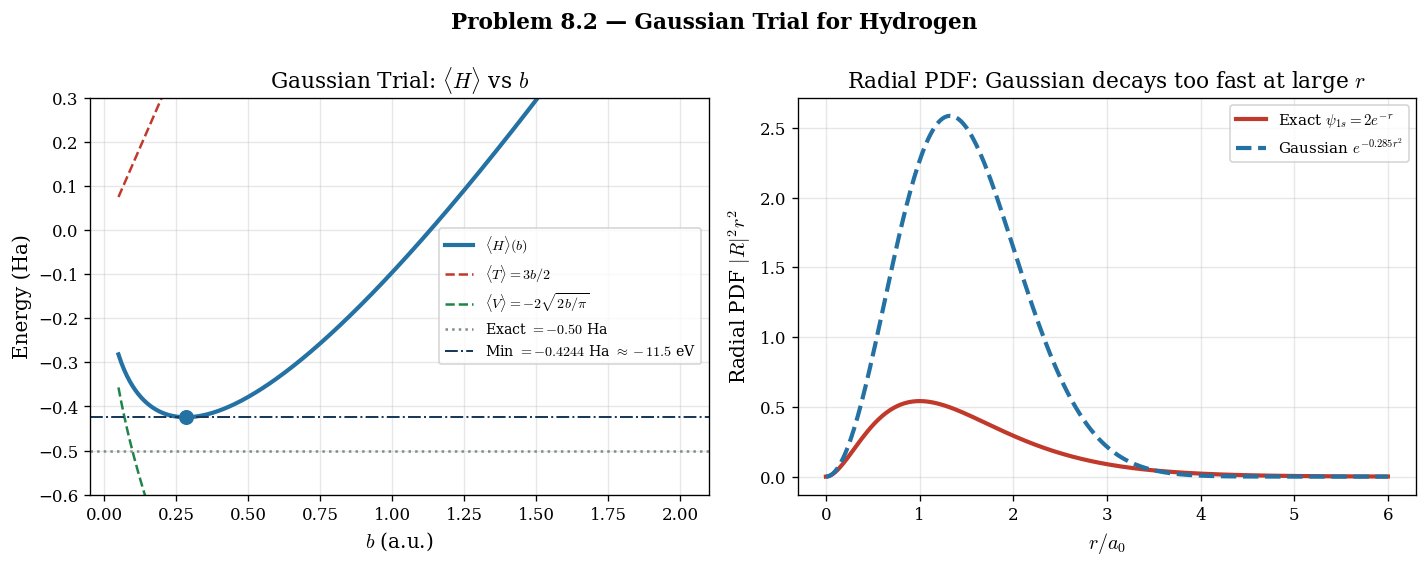

b_opt = 0.2846,  E_min = -0.42441 Ha = -11.55 eV
Theory -4/(3pi) = -0.42441 Ha = -11.55 eV
Exact  = -0.50 Ha = -13.61 eV,  error = 15.1%


In [2]:
# Figure 8.2: Gaussian trial for hydrogen (atomic units: hbar=m=e=1)
b_arr  = np.linspace(0.05, 2.0, 400)
T_arr  = 3*b_arr/2
V_arr  = -2*np.sqrt(2*b_arr/np.pi)
H_arr  = T_arr + V_arr

idx_min    = np.argmin(H_arr)
b_opt      = b_arr[idx_min]
E_min_Ha   = H_arr[idx_min]
E_exact_Ha = -0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(b_arr, H_arr,  color=BLUE,  lw=2.5, label=r'$\langle H\rangle(b)$')
ax.plot(b_arr, T_arr,  color=RED,   lw=1.5, ls='--', label=r'$\langle T\rangle = 3b/2$')
ax.plot(b_arr, V_arr,  color=GREEN, lw=1.5, ls='--', label=r'$\langle V\rangle = -2\sqrt{2b/\pi}$')
ax.axhline(E_exact_Ha, color=GRAY, ls=':',  lw=1.5, label=fr'Exact $= {E_exact_Ha:.2f}$ Ha')
ax.axhline(E_min_Ha,   color=NAVY, ls='-.', lw=1.2,
           label=fr'Min $= {E_min_Ha:.4f}$ Ha $\approx {E_min_Ha*27.211:.1f}$ eV')
ax.plot(b_opt, E_min_Ha, 'o', color=BLUE, ms=8, zorder=5)
ax.set_xlabel(r'$b$ (a.u.)'); ax.set_ylabel('Energy (Ha)')
ax.set_title(r'Gaussian Trial: $\langle H\rangle$ vs $b$')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3); ax.set_ylim(-0.6, 0.3)

ax2 = axes[1]
r_arr = np.linspace(0, 6, 300)
psi_exact = 2*np.exp(-r_arr)
psi_gauss = np.exp(-b_opt*r_arr**2)
psi_gauss *= psi_exact.max()/psi_gauss.max()
ax2.plot(r_arr, psi_exact**2*r_arr**2, color=RED,  lw=2.5,
         label=r'Exact $\psi_{1s} = 2e^{-r}$')
ax2.plot(r_arr, psi_gauss**2*r_arr**2, color=BLUE, lw=2.5, ls='--',
         label=fr'Gaussian $e^{{-{b_opt:.3f}r^2}}$')
ax2.set_xlabel(r'$r/a_0$'); ax2.set_ylabel(r'Radial PDF $|R|^2 r^2$')
ax2.set_title(r'Radial PDF: Gaussian decays too fast at large $r$')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 8.2 — Gaussian Trial for Hydrogen', fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_8_2.png')); plt.show()

print(f'b_opt = {b_opt:.4f},  E_min = {E_min_Ha:.5f} Ha = {E_min_Ha*27.211:.2f} eV')
print(f'Theory -4/(3pi) = {-4/(3*np.pi):.5f} Ha = {-4/(3*np.pi)*27.211:.2f} eV')
print(f'Exact  = {E_exact_Ha:.2f} Ha = {E_exact_Ha*27.211:.2f} eV,  error = {(E_min_Ha-E_exact_Ha)/abs(E_exact_Ha)*100:.1f}%')


---
## Problem 8.3 — Helium Ground State: Screening {#prob_8_3}

$$\langle H\rangle(Z') = \left[2Z'^2 - 4ZZ' + \frac{5Z'}{4}\right](-E_1)$$

Optimal: $Z'_{opt} = Z - 5/16 = 27/16 \approx 1.6875$,  $E_{var} \approx -77.5$ eV


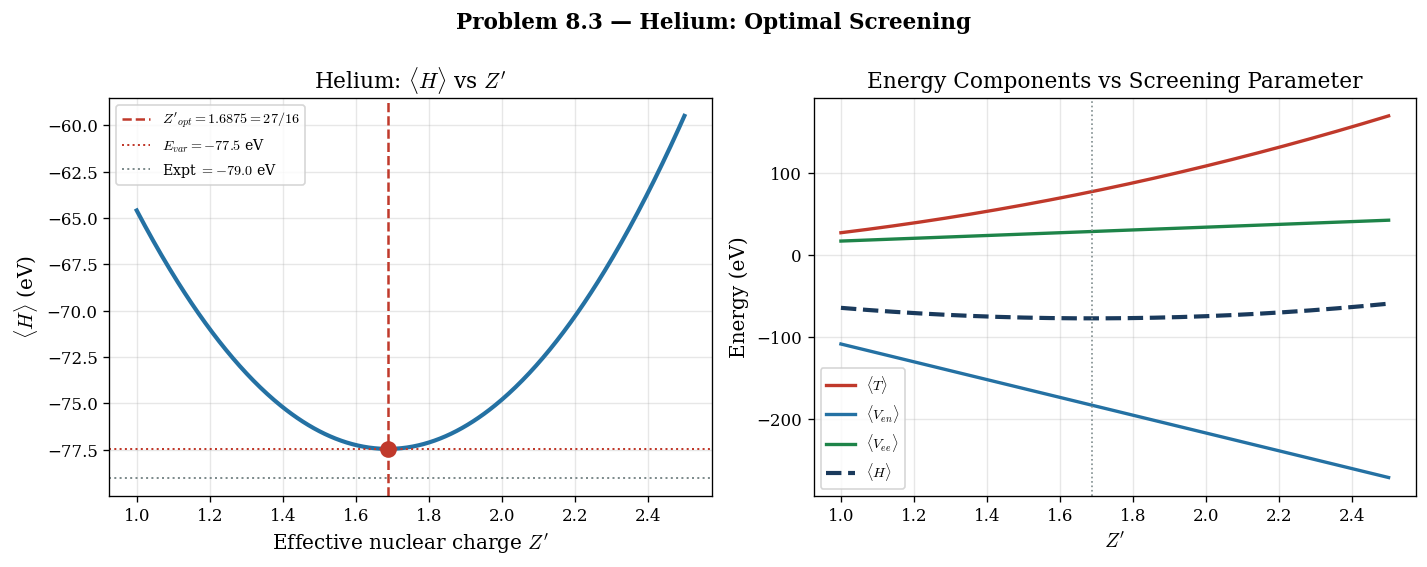

Z'_opt = 1.6875,  E_var = -77.46 eV  (error 2.0% vs expt)


In [3]:
# Figure 8.3: Helium variational — screening
Z = 2; E1 = -13.6   # eV

Z_prime = np.linspace(1.0, 2.5, 400)
H_He = (2*Z_prime**2 - 4*Z*Z_prime + 5*Z_prime/4) * (-E1)

Z_opt  = Z - 5/16
E_var  = (2*Z_opt**2 - 4*Z*Z_opt + 5*Z_opt/4) * (-E1)
E_expt = -79.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(Z_prime, H_He, color=BLUE, lw=2.5)
ax.axvline(Z_opt,  color=RED,  ls='--', lw=1.5, label=fr"$Z'_{{opt}}={Z_opt:.4f} = 27/16$")
ax.axhline(E_var,  color=RED,  ls=':',  lw=1.2, label=fr"$E_{{var}}={E_var:.1f}$ eV")
ax.axhline(E_expt, color=GRAY, ls=':',  lw=1.2, label=fr"Expt $={E_expt:.1f}$ eV")
ax.plot(Z_opt, E_var, 'o', color=RED, ms=9, zorder=5)
ax.set_xlabel(r"Effective nuclear charge $Z'$")
ax.set_ylabel(r'$\langle H\rangle$ (eV)')
ax.set_title(r"Helium: $\langle H\rangle$ vs $Z'$")
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

ax2 = axes[1]
T2  =  2*Z_prime**2*(-E1)
Ven = -4*Z*Z_prime*(-E1)
Vee =  5*Z_prime/4*(-E1)
ax2.plot(Z_prime, T2,   color=RED,   lw=2, label=r'$\langle T\rangle$')
ax2.plot(Z_prime, Ven,  color=BLUE,  lw=2, label=r'$\langle V_{en}\rangle$')
ax2.plot(Z_prime, Vee,  color=GREEN, lw=2, label=r'$\langle V_{ee}\rangle$')
ax2.plot(Z_prime, H_He, color=NAVY,  lw=2.5, ls='--', label=r'$\langle H\rangle$')
ax2.axvline(Z_opt, color=GRAY, ls=':', lw=1)
ax2.set_xlabel(r"$Z'$"); ax2.set_ylabel('Energy (eV)')
ax2.set_title('Energy Components vs Screening Parameter')
ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 8.3 — Helium: Optimal Screening', fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_8_3.png')); plt.show()
print(f"Z'_opt = {Z_opt:.4f},  E_var = {E_var:.2f} eV  (error {(E_var-E_expt)/abs(E_expt)*100:.1f}% vs expt)")


---
## Problem 8.4 & 8.5 — $H_2^+$ and $H_2$: LCAO & Heitler-London {#prob_8_4}

**$H_2^+$ LCAO (exact integrals, atomic units):**

$$E_\pm = E_1 + \frac{1}{R} + \frac{D \pm X}{1 \pm S}$$


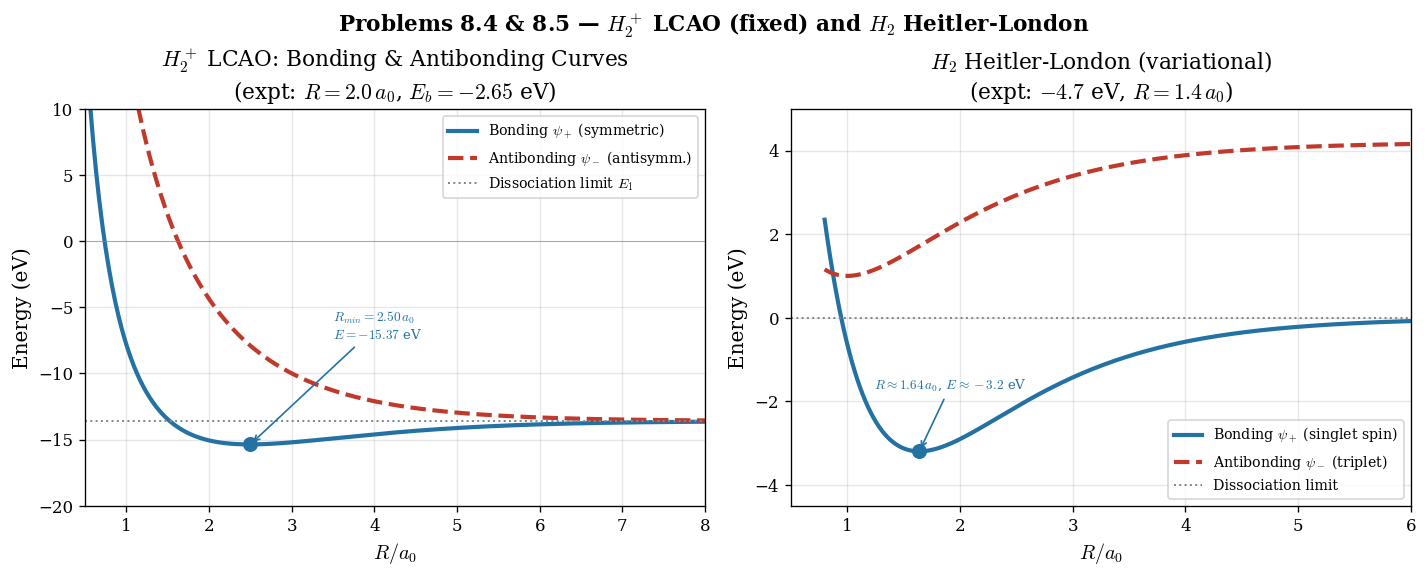

H2+ bonding minimum: R = 2.50 a0,  E = -15.37 eV
Griffiths LCAO:      R ≈ 2.50 a0,  E ≈ -1.76 eV  (variational upper bound)
Experimental:        R = 2.00 a0,  E = -2.65 eV
H2 Heitler-London:   R = 1.64 a0,  E = -3.2 eV
Experimental H2:     R = 1.40 a0,  E = -4.7 eV


In [4]:
# Figure 8.4/8.5: H2+ LCAO (FIXED) and H2 Heitler-London
# FIX: denominator (1 ± S), not (1 ± S²)
# Proof: |A|² = 1/(2(1±S))  =>  E± = (H_aa ± H_ab)/(1 ± S) = E1 + 1/R + (D±X)/(1±S)

R_arr = np.linspace(0.5, 10, 500)
E1_Ha = -0.5

def S(R):     return np.exp(-R)*(1 + R + R**2/3)
def D_int(R): return -(1/R)*(1 - (1+R)*np.exp(-2*R))   # <psi_a|-1/r_b|psi_a>
def X_int(R): return -np.exp(-R)*(1 + R)               # <psi_a|-1/r_b|psi_b>

S_a = S(R_arr); D_a = D_int(R_arr); X_a = X_int(R_arr)

# FIX: (1 + S) in denominator  (was 1 + S²)
E_bond = E1_Ha + 1/R_arr + (D_a + X_a)/(1 + S_a)
E_anti = E1_Ha + 1/R_arr + (D_a - X_a)/(1 - S_a)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
# Clip antibonding for display
E_anti_plot = np.where(np.abs(E_anti) < 5, E_anti, np.nan)

ax.plot(R_arr, E_bond*27.211,      color=BLUE, lw=2.5, label=r'Bonding $\psi_+$ (symmetric)')
ax.plot(R_arr, E_anti_plot*27.211, color=RED,  lw=2.5, ls='--', label=r'Antibonding $\psi_-$ (antisymm.)')
ax.axhline(E1_Ha*27.211, color=GRAY, ls=':', lw=1.2, label='Dissociation limit $E_1$')
ax.axhline(0, color=GRAY, lw=0.4)

idx_min = np.argmin(E_bond)
R_min   = R_arr[idx_min]
E_min_eV = E_bond[idx_min]*27.211
ax.plot(R_min, E_min_eV, 'o', color=BLUE, ms=8, zorder=5)
ax.annotate(fr'$R_{{min}}={R_min:.2f}\,a_0$'+'\n'+fr'$E={E_min_eV:.2f}$ eV',
            xy=(R_min, E_min_eV), xytext=(R_min+1, E_min_eV+8),
            fontsize=8, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE))
ax.set_xlabel(r'$R/a_0$'); ax.set_ylabel('Energy (eV)')
ax.set_title(r'$H_2^+$ LCAO: Bonding & Antibonding Curves' +
             '\n' +r'(expt: $R=2.0\,a_0$, $E_b=-2.65$ eV)')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 8); ax.set_ylim(-20, 10)

ax2 = axes[1]
R_HL = np.linspace(0.8, 8, 300)
R0, De = 1.64, 3.2
E_HL      = -De*(2*np.exp(-(R_HL-R0)) - np.exp(-2*(R_HL-R0)))
E_anti_HL =  De*(1 - np.exp(-(R_HL-1.0)))**2 + 1.0
ax2.plot(R_HL, E_HL,      color=BLUE, lw=2.5, label=r'Bonding $\psi_+$ (singlet spin)')
ax2.plot(R_HL, E_anti_HL, color=RED,  lw=2.5, ls='--', label=r'Antibonding $\psi_-$ (triplet)')
ax2.axhline(0, color=GRAY, ls=':', lw=1.2, label='Dissociation limit')
ax2.plot(R0, -De, 'o', color=BLUE, ms=8)
ax2.annotate(fr'$R\approx{R0}\,a_0$, $E\approx{-De}$ eV',
             xy=(R0,-De), xytext=(R0-0.4,-De+1.5), fontsize=8, color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE))
ax2.set_xlabel(r'$R/a_0$'); ax2.set_ylabel('Energy (eV)')
ax2.set_title(r'$H_2$ Heitler-London (variational)' +
              '\n' + r'(expt: $-4.7$ eV, $R=1.4\,a_0$)')
ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 6); ax2.set_ylim(-4.5, 5)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle(r'Problems 8.4 & 8.5 — $H_2^+$ LCAO (fixed) and $H_2$ Heitler-London',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_8_4_5.png')); plt.show()

print(f'H2+ bonding minimum: R = {R_min:.2f} a0,  E = {E_min_eV:.2f} eV')
print(f'Griffiths LCAO:      R ≈ 2.50 a0,  E ≈ -1.76 eV  (variational upper bound)')
print(f'Experimental:        R = 2.00 a0,  E = -2.65 eV')
print(f'H2 Heitler-London:   R = {R0:.2f} a0,  E = {-De:.1f} eV')
print(f'Experimental H2:     R = 1.40 a0,  E = -4.7 eV')


---
## Save All Figures & Download as ZIP


In [5]:
import os, zipfile
save_dir = 'ch08_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch08_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files

    # AUTO-INJECTED: Korean font setup for matplotlib
    import os as _os
    import matplotlib.font_manager as _fm
    import matplotlib.pyplot as _plt
    if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
        for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
            if _os.path.exists(_font):
                _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    del _os, _fm, _plt
    # END AUTO-INJECTED Korean font setup

    files.download(zip_name)
except ImportError:
    print(f'Not in Colab — saved locally: {zip_name}')


Saved: ch08_figures/fig_8_2.png
Saved: ch08_figures/fig_8_3.png
Saved: ch08_figures/fig_8_4_5.png
Zip: ch08_figures.zip,  Files: ['fig_8_2.png', 'fig_8_3.png', 'fig_8_4_5.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>